In [1]:
import os
import textwrap
import json

def list_subdirectories(flux_dir):
    return [
        name for name in os.listdir(flux_dir)
        if os.path.isdir(os.path.join(flux_dir, name)) and 'logs' not in name
    ]

def list_subdirectories2(filtered_flux_dir):
    return [
        name.removeprefix('filtered_') for name in os.listdir(filtered_flux_dir)
        if os.path.isdir(os.path.join(filtered_flux_dir, name)) and 'logs' not in name
    ]


# Get the set of subdirectories present in both lists
def get_concurrent_subdirectories(flux_dir, filtered_flux_dir):
    subdirs1 = set(list_subdirectories(flux_dir))
    subdirs2 = set(list_subdirectories2(filtered_flux_dir))
    return list(subdirs1 & subdirs2)


In [89]:
flux_results_path = '/data3/jhpark/data_synth/coco/person'
filtered_flux_results_path = '/data3/jhpark/filtered_data_synth/coco/person'
flux_results_dirs = list_subdirectories(flux_results_path)
filtered_flux_results_dirs = list_subdirectories2(filtered_flux_results_path)

exp_dirs = get_concurrent_subdirectories(flux_results_path, filtered_flux_results_path)


In [90]:
exp_dirs

['e62e75c0-2fc6-4535-8797-bb0d6e2f0bd2',
 '155f9971-04d5-49f7-b0fd-651c9994dd3d',
 '1343a6a3-09e7-48bf-bde8-e3f1e6341201',
 '9ee8c379-46da-4ce8-84b0-051429fa112c',
 'ed7960aa-fd6b-4dc2-b946-cc352278f489',
 '6ecdaea0-17fc-44c1-9f6b-5caeabcbbf79',
 '4b2c146f-bca5-410c-a581-15d2fc7ba606',
 'eafe85ce-2877-4ead-943e-7f0504f0b573',
 '051697b2-fb60-4bf8-831f-2fc2f8b4beba',
 '7afd6995-4b59-4802-88c4-2774516a17ea',
 '3b025bde-c8d3-486c-b2f3-21d41b52ad5c',
 '01bf0480-798b-429c-b4b8-ad85ab20dd87',
 '072ad58f-51e4-4d8c-a239-8aa6499cfa94',
 'c6dd2dae-555f-459e-9bf8-d379b95fae07',
 '4cc60863-6039-4b31-8a6a-10904e5a754e',
 'db7c66a0-33e9-4d7b-9db3-3e6e7990efc9',
 '0ace3123-1717-4bb0-9545-ef3049308122',
 '0921cc35-8995-4ae1-8894-90c83e50db58',
 'b719f018-5327-4eb5-849a-790f8542a7e0',
 '017c8535-8dc4-42b8-a658-3cb36f8a9109',
 '7495e8ae-2bf8-4624-bc24-6f3772486db7',
 '8b57bdaa-1ac3-47b0-b9a2-d98e9b43034c',
 '5b186aa8-a24a-48c1-bb59-353e040825f2',
 '219a5b40-6c26-4886-a5ec-692b6a3b8c86',
 '79703f09-ed31-

In [91]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def plot_comparison_png(parent_dir, subdirectory):
    comparison_path = os.path.join(parent_dir, subdirectory, "comparison.png")
    img = mpimg.imread(comparison_path)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{subdirectory}/comparison.png")
    plt.show()


In [92]:
def plot_explanations(parent_dir, subdirectory):
    metadata_path = os.path.join(parent_dir, subdirectory, "metadata.json")
    print(metadata_path)
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)
    artifact_image_path = os.path.join(parent_dir, subdirectory, "artifact_image.png")
    img = mpimg.imread(artifact_image_path)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')
    for idx, artifact in enumerate(metadata['artifacts']):
        bbox = artifact['target_bbox']
        x1, y1, x2, y2 = bbox
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='r', facecolor='none')
        plt.gca().add_patch(rect)
        plt.gca().text(x1, y1 - 5, str(idx) +' ' + artifact['artifact_type'], color='white', fontsize=12, weight='bold', va='bottom', ha='left', bbox=dict(facecolor='r', alpha=0.5, edgecolor='none', pad=1))
        print('\n'.join(textwrap.wrap(artifact['explanation'], width=80)))
        print('--------------------------------')
    plt.show()

In [220]:
flux_results_iter = iter(exp_dirs)

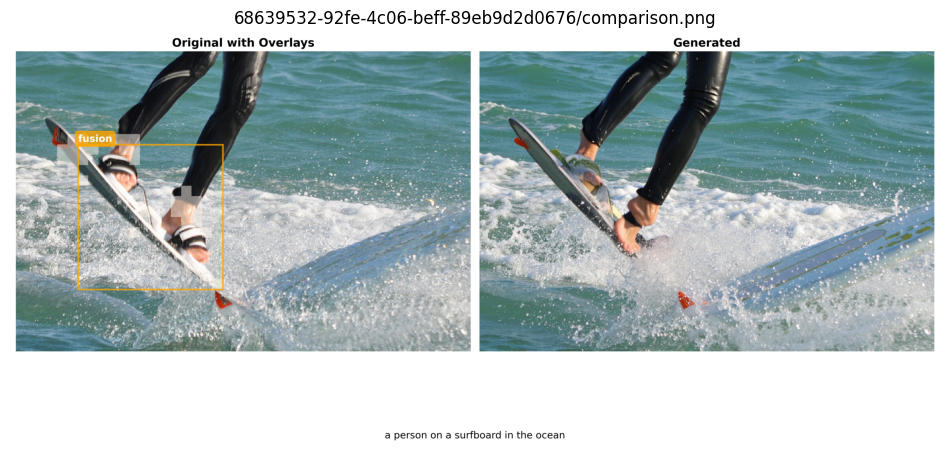

/data3/jhpark/filtered_data_synth/coco/person/68639532-92fe-4c06-beff-89eb9d2d0676/metadata.json
The feet appear to be merged with the wakeboard, with no clear separation
between them. The straps seem to be missing or blended into the board.
--------------------------------


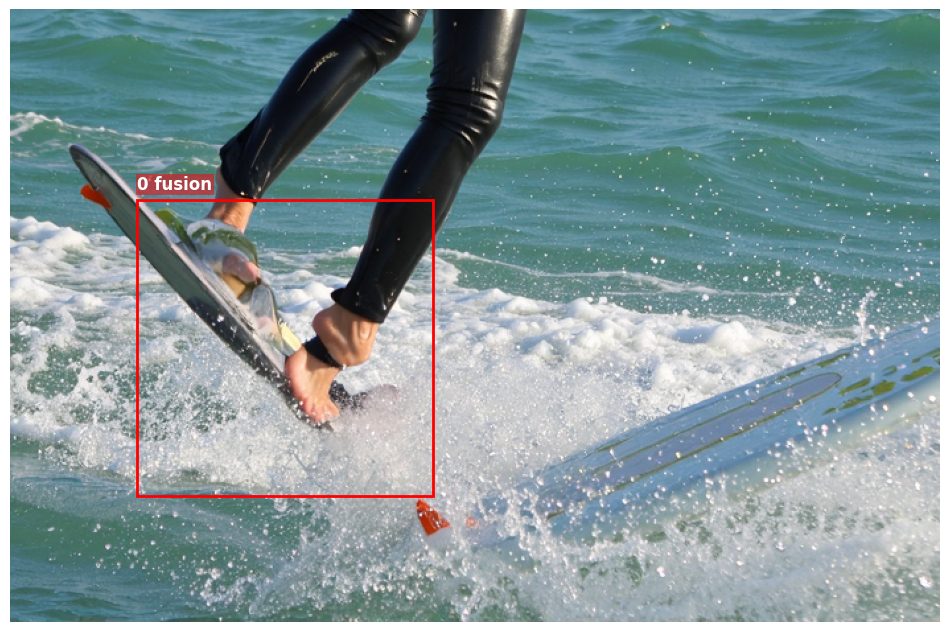

In [219]:
flux_result = next(flux_results_iter)
plot_comparison_png(flux_results_path, flux_result)
plot_explanations(filtered_flux_results_path, flux_result)